# 05 · A research agent's forecast, traced

**Supports agenda block 9** ("Research Agents: Strategies That Show Their
Work"). Rather than firing a live multi-agent LLM pipeline at everyone in
this room at once - which needs API keys, the book's own Docker image,
and isn't reproducible on a fixed schedule - we walk through one complete,
real, already-run trace of the book's Chapter 24 `AIAForecaster` pipeline,
bundled with this repo. Every number below came from that one real run;
nothing here is invented or reconstructed after the fact.

The pipeline has four stages: independent specialists, correlation-aware
aggregation, adversarial debate, and a supervisor's final call. Each
section below runs one stage.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

if "COLAB_RELEASE_TAG" in os.environ:
    repo_dir = Path(os.environ.get("PACKT_WORKSHOP_DIR", "/content/packt-workshop"))
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/ml4t/packt-workshop.git",
                repo_dir,
            ],
            check=True,
        )
    ready = repo_dir.parent / ".packt-workshop-ready"
    if not ready.exists():
        # Colab's kernel already has numpy imported before this cell runs. Installing a
        # different numpy from requirements-colab.txt overwrites the files on disk but not
        # the compiled submodules already cached in this process, so importing a numpy
        # submodule for the first time later (e.g. via ml4t.engineer) mixes the new files
        # with the stale cached extension and raises ImportError. Put numpy back to the
        # version this process already has loaded once the rest of the install is done.
        import numpy as _colab_numpy

        colab_numpy_version = _colab_numpy.__version__
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "-r",
                repo_dir / "requirements-colab.txt",
            ],
            check=True,
        )
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "--force-reinstall",
                "--no-deps",
                f"numpy=={colab_numpy_version}",
            ],
            check=True,
        )
        ready.touch()
    os.chdir(repo_dir / "notebooks")

In [2]:
import json

import pandas as pd

DATA_DIR = "../data"

with open(f"{DATA_DIR}/research_agent_trace.json") as f:
    trace = json.load(f)

trace["provenance"]

{'source_repo': 'github.com/stefan-jansen/machine-learning-for-trading',
 'source_path': '24_autonomous_agents/forecast_traces/08_forecasting_pipeline_20260609T142158Z_24e083e7fe54.json',
 'provider': 'claude-sonnet-4-20250514',
 'created_at': '2026-06-09T14:21:58+00:00',
 'run_id': '24e083e7fe54',
 'note': "Trimmed for this workshop: keeps every agent-generated number and piece of reasoning verbatim, drops the raw web search results (third-party scraped snippets/URLs) each specialist queried along the way. The full raw trace, including those search results, lives at source_path above in the book's companion repo."}

## The question

A real, open forecasting question - it hadn't resolved at the time of this
run, and still hasn't as of this workshop.

In [3]:
q = trace["question"]
print(q["question"])
print(q["description"])
print(f"\nMarket-implied probability at the time: {q['current_market_price']}")

Will the Federal Reserve hike rates in 2026?
Resolves YES if the upper bound of the federal funds target rate is increased at any point between January 1, 2026 and the Fed's December 2026 meeting (scheduled December 8-9, 2026).

Market-implied probability at the time: 0.545


## Step 1 - three specialists, independently

Each specialist searches for evidence and produces its own probability and
rationale, with no visibility into the other specialists' answers.

In [4]:
agents = pd.DataFrame(trace["agents"]).set_index("agent_id")
agents["rationale"] = agents["rationale"].str.slice(0, 160) + "..."
agents[["p_yes", "rationale"]]

,p_yes,rationale
agent_id,,
agent_0,0.25,"Based on the evidence, the Fed is currently ma..."
agent_1,0.25,The Fed's December 2025 dot plot shows officia...
agent_2,0.62,Based on recent market developments and econom...


Two specialists read the Fed's own guidance as pointing toward cuts;
one reads the same inflation print as hike-forcing. A 37-percentage-point
spread on the same underlying facts is exactly the disagreement the next
two stages exist to surface, not paper over.

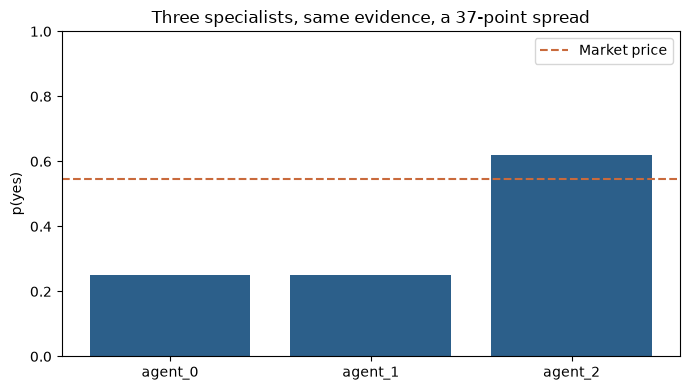

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(agents.index, agents["p_yes"], color="#2c5f8a")
ax.axhline(q["current_market_price"], color="#c96a3c", linestyle="--", label="Market price")
ax.set_ylabel("p(yes)")
ax.set_title("Three specialists, same evidence, a 37-point spread")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## Step 2 - aggregation (Neyman, correlation-adjusted)

A simple average would overweight agents who happen to share the same
information sources. The Neyman aggregator estimates how correlated the
specialists' answers are (ρ) and extremizes the pooled estimate to correct
for it.

In [6]:
agg = trace["aggregation"]
print(f"Raw average:                 {agg['raw_probability']:.4f}")
print(f"Extremization factor:        {agg['extremization_factor']:.4f}")
print(f"Extremized probability:      {agg['extremized_probability']:.4f}")
print(f"Effective independent agents: {agg['effective_n']:.2f} of {len(trace['agents'])}")

Raw average:                 0.3733
Extremization factor:        1.3693
Extremized probability:      0.3266
Effective independent agents: 1.88 of 3


Effective N below the actual agent count is the tell: most of the
"three opinions" overlap, so the aggregator down-weights how much genuine
independent evidence three agents actually supplied.

## Step 3 - adversarial debate, three rounds

A bull and a bear agent argue from the same evidence base. Each round is
scored independently - the debate doesn't stop until a fixed round limit
or until both sides agree, whichever comes first.

In [7]:
rounds = pd.DataFrame(trace["debate"]["rounds"])[
    ["round_number", "bull_probability", "bear_probability", "consensus_reached"]
].set_index("round_number")
rounds

,bull_probability,bear_probability,consensus_reached
round_number,,,
1,0.68,0.18,False
2,0.68,0.20,False
3,0.65,0.20,False


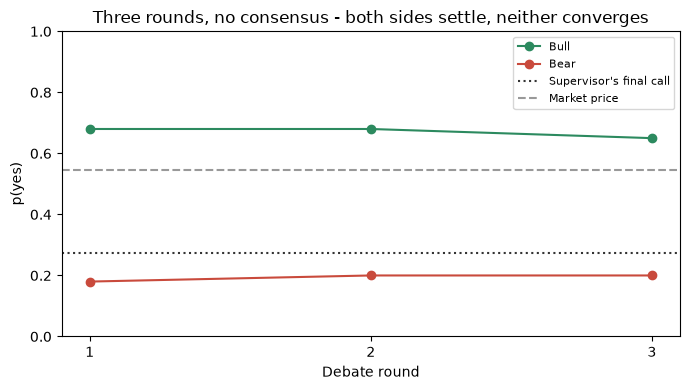

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds.index, rounds["bull_probability"], marker="o", color="#2c8a5f", label="Bull")
ax.plot(rounds.index, rounds["bear_probability"], marker="o", color="#c94a3c", label="Bear")
ax.axhline(
    trace["final_probability"], color="#333333", linestyle=":", label="Supervisor's final call"
)
ax.axhline(q["current_market_price"], color="#999999", linestyle="--", label="Market price")
ax.set_xlabel("Debate round")
ax.set_ylabel("p(yes)")
ax.set_xticks(rounds.index)
ax.set_ylim(0, 1)
ax.set_title("Three rounds, no consensus - both sides settle, neither converges")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
print("Round 1 bull argument (excerpt):")
print(trace["debate"]["rounds"][0]["bull_argument"][:280] + "...")
print()
print("Round 1 bear argument (excerpt):")
print(trace["debate"]["rounds"][0]["bear_argument"][:280] + "...")

Round 1 bull argument (excerpt):
The Federal Reserve will likely need to hike rates in 2026 due to persistent inflationary pressures and economic resilience that will force them to abandon their dovish stance. With inflation running at 2.9% - well above the Fed's 2% target - and showing signs of becoming entrenc...

Round 1 bear argument (excerpt):
The Federal Reserve will not hike rates in 2026 because the current economic trajectory points toward disinflation and potential recession risks that will force the Fed to maintain or even lower rates. The Bull's inflation concerns are misplaced - the 2.9% inflation reading is li...


Consensus was never reached across all three rounds - both sides settle
rather than converge, and the arguments show exactly why: bull and bear
keep re-reading the same December 2025 Fed dot plot in opposite
directions (bull calls it "outdated guidance," bear calls it "the
collective judgment of Fed officials"). The debate doesn't manufacture
agreement; it makes the disagreement legible.

## Step 4 - the supervisor's final call

The supervisor reviews the full record - specialist estimates,
aggregation, the debate transcript - names the disagreements a careful
reader would name, runs its own clarifying research, and still commits to
one number.

In [10]:
for d in trace["supervisor"]["disagreements"]:
    print("-", d)

print(f"\nFinal probability: {trace['final_probability']:.4f}")
print(f"Final confidence:  {trace['final_confidence']}")
print(f"Market price was:  {q['current_market_price']}")

- Major probability split: agents 0 and 1 assign 25% probability while agent 2 assigns 62% - a 37 percentage point difference
- Conflicting interpretation of Fed dot plot: agent 1 claims it shows expectation of rate cuts in 2026, while agent 2 suggests conditions favor rate hikes
- Different emphasis on inflation data: agent 2 highlights 2.9% inflation as concerning, but agents 0 and 1 don't mention current inflation levels
- Incomplete rationales from all agents make it difficult to assess the strength of their reasoning

Final probability: 0.2737
Final confidence:  0.6
Market price was:  0.545


The final call lands well below the market price at the time, driven
mainly by the bear case's reading of Fed guidance and the two specialists
who agreed with it.

## Why this is the run worth tracing

A pipeline that always converges to consensus would be suspicious - it
would mean the debate phase does nothing. This run didn't converge, and
the trace shows exactly where and why the two readings diverge, which is
the actual audit value: not "the agents agreed," but "you can see
precisely what they disagreed about and why the supervisor weighted it
the way it did."

## What NOT to claim from this

This run has no resolved outcome yet - it can't resolve before December
2026 - so there is no accuracy or calibration number to report here;
`0.2737` is a probability, not a graded prediction. Chapter 24's own
notebook 9 does demonstrate Brier-score / log-loss / calibration-transform
arithmetic, but on an **author-selected synthetic panel assembled after
outcomes were known**, built to make the scoring-rule math reproducible -
not a measurement of this pipeline's real forecasting accuracy. Don't
present those notebook-9 numbers as if they were.

**Full raw trace** (including every search query and result each
specialist issued along the way): `trace["provenance"]["source_path"]`
above, in the book's own companion repo. See `../docs/research_agent_demo.md`
for how to run the live pipeline yourself, end to end.

**This is the last notebook.** Block 10 ("Where to Go Next: From Backtest
to Production, and Q&A") is slides only - deployment risks this session's
backtest doesn't cover, and where to go next depending on which part of
today's workflow you want to go deeper on.